**Dataset Source/Dataset Selection:** UCI Machine Learning Repository

The Wisconsin Diagnostic Breast Cancer (WDBC) dataset is a public
classification dataset originally available through the UCI Machine
Learning Repository. The dataset contains 569 instances and 30
numerical input features and is used to classify tumors as malignant
or benign.
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


Wisconsin Diagnostic Breast Cancer (WDBC)

*   569 observations
*   30 input features
*   Binary classification
*   Target: whether the tumor is malignant or benign

**Problem Statement:**

Develop and compare multiple machine learning classification models to predict whether a breast tumor is malignant or benign using diagnostic measurements from the Wisconsin Diagnostic Breast Cancer dataset.

**Input**

30 numerical diagnostic features such as measurements related to:

radius

texture

perimeter

area

smoothness

compactness

concavity

symmetry

fractal dimension

**Output**

Binary prediction:
0 → Malignant
1 → Benign


**Train/Test Split**

80% training

≈ 455 records

20% testing

≈ 114 records

**Dataset Description**

Wisconsin Diagnostic Breast Cancer (WDBC)
 dataset contains 569 instances and 30 numerical input features. It is a binary classification problem in which the objective is to classify a breast tumor as malignant or benign based on diagnostic measurements. The dataset satisfies the assignment requirements of a minimum of 500 instances and 12 features.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

In [ ]:
print('(observations, features) = ',X.shape)

(observations, features) =  (569, 30)


In [ ]:
print("=========Train Test split data ==================")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
#print("Train dataset size =",X_train)
#print("Test dataset size =",X_test)

=========Train Test split data ==================


In [ ]:
print("========Logistic Regression ===============")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

========Logistic Regression ===============


In [ ]:
print("==========Decision Tree ===============")
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred = decision_tree.predict(X_test)
y_prob = decision_tree.predict_proba(X_test)[:, 1]

==========Decision Tree ===============


In [ ]:
print("=============KNN Model ==============")
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(
        n_neighbors=7
    ))
])

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
y_prob = knn_model.predict_proba(X_test)[:, 1]

=============KNN Model ==============


In [ ]:
print("==========Gaussian Naive Bayes ===============")
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

y_pred = naive_bayes.predict(X_test)
y_prob = naive_bayes.predict_proba(X_test)[:, 1]

==========Guassian Naive Bayes ===============


In [ ]:
print("============Random Forest =================")
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)
y_prob = random_forest.predict_proba(X_test)[:, 1]

============Random Forest =================


In [ ]:
print("=============Model Evaluation ===============")
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_test, y_pred
        )
    }

=============Model Evaluation ===============


In [ ]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "kNN": knn_model,
    "Naive Bayes": naive_bayes,
    "Random Forest": random_forest
}
results = []

for name, model in models.items():

    #model.fit(X_train, y_train)

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["ML Model Name"] = name

    results.append(metrics)

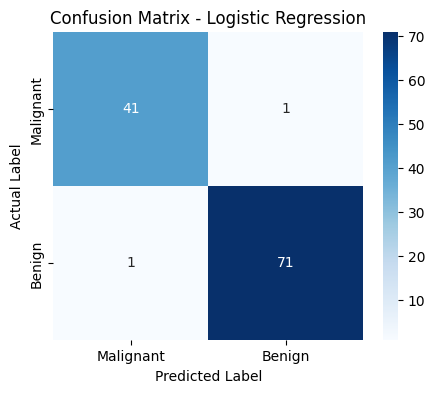

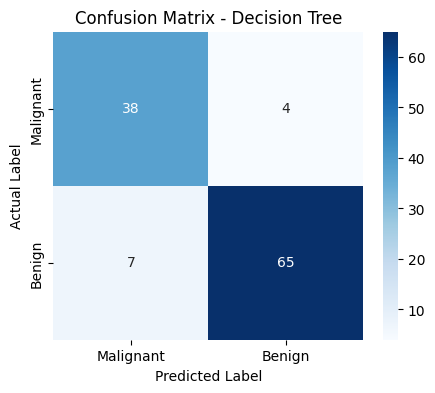

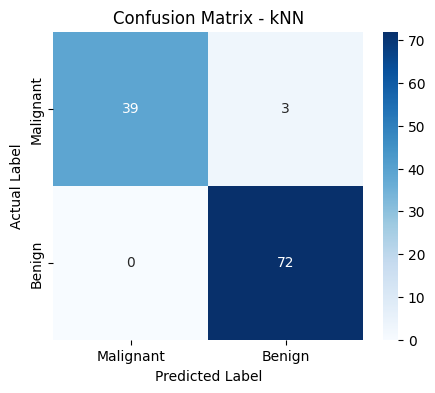

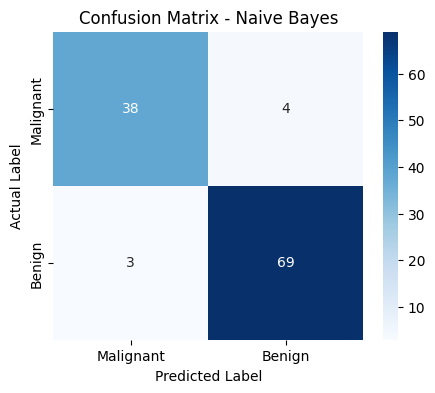

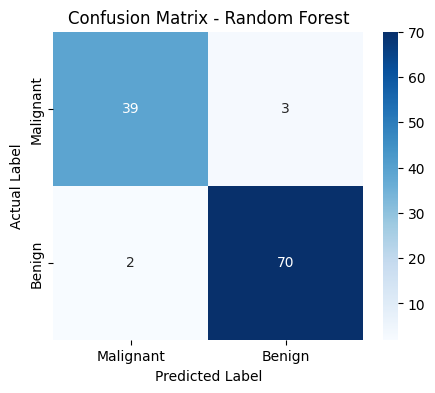

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrices for all models
for name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

In [ ]:
from sklearn.metrics import classification_report

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("=" * 70)
    print(f"Classification Report - {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Malignant", "Benign"],
            digits=4
        )
    )

Classification Report - Logistic Regression
              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

Classification Report - Decision Tree
              precision    recall  f1-score   support

   Malignant     0.8444    0.9048    0.8736        42
      Benign     0.9420    0.9028    0.9220        72

    accuracy                         0.9035       114
   macro avg     0.8932    0.9038    0.8978       114
weighted avg     0.9061    0.9035    0.9041       114

Classification Report - kNN
              precision    recall  f1-score   support

   Malignant     1.0000    0.9286    0.9630        42
      Benign     0.9600    1.0000    0.9796        72

    accuracy                         0.9737       114
   macro avg     0

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "ML Model Name",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1",
        "MCC"
    ]
]

results_df.round(4)

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
1,Decision Tree,0.9035,0.9373,0.9420,0.9028,0.9220,0.7969
2,kNN,0.9737,0.9884,0.9600,1.0000,0.9796,0.9442
3,Naive Bayes,0.9386,0.9878,0.9452,0.9583,0.9517,0.8676
4,Random Forest,0.9561,0.9944,0.9589,0.9722,0.9655,0.9054


| ML Model Name           |   Accuracy |        AUC |  Precision |     Recall |         F1 |        MCC |
| ----------------------- | ---------: | ---------: | ---------: | ---------: | ---------: | ---------: |
| **Logistic Regression** | **0.9825** | **0.9954** | **0.9861** |     0.9861 | **0.9861** | **0.9623** |
| Decision Tree           |     0.9035 |     0.9373 |     0.9420 |     0.9028 |     0.9220 |     0.7969 |
| kNN                     |     0.9737 |     0.9884 |     0.9600 | **1.0000** |     0.9796 |     0.9442 |
| Naive Bayes             |     0.9386 |     0.9878 |     0.9452 |     0.9583 |     0.9517 |     0.8676 |
| **Random Forest**       |     0.9561 |     0.9944 |     0.9589 |     0.9722 |     0.9655 |     0.9054 |


Performance of each models

**Logistic Regression**

Logistic Regression achieved the best overall performance, with the highest Accuracy (98.25%), AUC (99.54%), Precision (98.61%), F1 Score (98.61%) and MCC (96.23%). This indicates that the model provides excellent discrimination and balanced classification performance on the WDBC dataset.

**Decision Tree**

Decision Tree achieved the lowest overall performance among the five models, with an accuracy of 90.35% and MCC of 79.69%. Although it can capture non-linear relationships, its performance was lower than the other models for this dataset.

**KNN**

KNN achieved very strong performance, with 97.37% accuracy and 98.84% AUC. It achieved the highest recall of 100%, meaning all positive-class instances in the test set were correctly identified. Its high performance is supported by feature standardization, which is important for a distance-based algorithm.

**Naive Bayes**

Gaussian Naive Bayes achieved 93.86% accuracy and 98.78% AUC. Although its accuracy was lower than Logistic Regression and KNN, its AUC was still high, indicating strong ability to distinguish between the two classes.

**Random Forest**

Random Forest achieved 95.61% accuracy and 99.44% AUC. It substantially outperformed the individual Decision Tree, demonstrating the benefit of combining multiple trees through an ensemble approach.

**Overall Winner: Logistic Regression**

Logistic Regression was selected as the overall winner because it achieved the highest accuracy, AUC, precision, F1 score and MCC among the evaluated models. Its recall was also very high at 98.61%. Therefore, it provided the most balanced overall performance on the selected WDBC dataset.

In [ ]:
#save models for streamlit app rendering
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(logistic_model, "model/logistic_regression.joblib")
joblib.dump(decision_tree, "model/decision_tree.joblib")
joblib.dump(knn_model, "model/knn.joblib")
joblib.dump(naive_bayes, "model/naive_bayes.joblib")
joblib.dump(random_forest, "model/random_forest.joblib")

print("All trained models saved successfully.")

All trained models saved successfully.


In [ ]:
os.listdir("model")

['decision_tree.joblib',
 'random_forest.joblib',
 'naive_bayes.joblib',
 'logistic_regression.joblib',
 'knn.joblib']

In [ ]:
for filename in os.listdir("model"):
    filepath = os.path.join("model", filename)
    print(filename, os.path.getsize(filepath), "bytes")

decision_tree.joblib 3945 bytes
random_forest.joblib 855225 bytes
naive_bayes.joblib 2535 bytes
logistic_regression.joblib 3089 bytes
knn.joblib 115630 bytes


In [ ]:
!zip -r models.zip model

  adding: model/ (stored 0%)
  adding: model/decision_tree.joblib (deflated 58%)
  adding: model/random_forest.joblib (deflated 81%)
  adding: model/naive_bayes.joblib (deflated 30%)
  adding: model/logistic_regression.joblib (deflated 32%)
  adding: model/knn.joblib (deflated 10%)


In [ ]:
from google.colab import files

files.download("models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
test_data = X_test.copy()
test_data["target"] = y_test.values

test_data.to_csv(
    "test_data.csv",
    index=False
)

print(test_data.shape)

(114, 31)


In [ ]:
files.download("test_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>